# Universal Decomposition of Perturbation Effects

In this tutorial, we will systematically analyze a perturb-seq dataset by decomposing the perturbation effects on to the globally defined principal axes of cell state transitions.

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

import scanpy as sc

## Load and preprocess the perturb-seq dataset

Load the example perturb-seq dataset. This is a CRISPRi dataset.

In [2]:
adata = sc.read_h5ad('data/tutorial_data/AdamsonWeissman2016_GSM2406681_10X010.h5ad')
adata

AnnData object with n_obs × n_vars = 65337 × 32738
    obs: 'perturbation', 'read count', 'UMI count', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts'
    var: 'ensembl_id', 'ncounts', 'ncells'

Normalize the total count of each cell

In [3]:
sc.pp.normalize_total(adata, target_sum=1e4)

Let's have a look at what genes are perturbed in this dataset and the number of cells for each perturbation.

In [4]:
condition_col = 'perturbation'
condition_cell_counts = adata.obs[condition_col].value_counts()
for c in condition_cell_counts.index:
    print(f'{c}\t{condition_cell_counts.loc[c]}')

63(mod)_pBA580	6010
Gal4-4(mod)_pBA582	1283
IER3IP1_pDS002	1222
SEC61B_pDS033	1185
ASCC3_pDS052	1142
DNAJC19_pDS026	1000
HSPA9_pDS088	894
HSPA5_pDS017	881
YIPF5_pDS186	817
SAMM50_pDS156	817
TARS_pDS405	803
XRN1_pDS411	788
GBF1_pDS043	760
TIMM23_pDS284	757
DAD1_pDS499	752
SEC61A1_pDS032	740
AMIGO3_pDS434	715
SRPRB_pDS404	703
SRP68_pDS403	699
UFM1_pDS040	692
TELO2_pDS496	691
FECH_pDS494	683
MRPL39_pDS498	683
IARS2_pDS091	673
SCYL1_pDS160	669
DARS_pDS495	664
IDH3A_pDS393	663
DERL2_pDS042	656
SEC63_pDS218	654
TTI2_pDS408	653
SYVN1_pDS442	650
SEC61G_pDS440	650
SPCS3_pDS402	647
OST4_pDS353	646
ATP5B_pDS055	644
SLMO2_pDS433	637
FARSB_pDS390	632
TMED10_pDS036	626
PSMD4_pDS488	625
EIF2B4_pDS491	625
SLC35B1_pDS046	621
EIF2B2_pDS463	615
ASCC3_pDS051	614
DDRGK1_pDS041	607
GMPPB_pDS391	606
SLC39A7_pDS219	601
SRPR_pDS482	591
TIMM44_pDS430	590
SPCS2_pDS401	587
UFL1_pDS410	585
PDIA6_pDS029	583
IER3IP1_pDS110	582
YIPF5_pDS226	574
MRGBP_pDS124	570
SCYL1_pDS159	561
P4HB_pDS397	560
MANF_pDS027	554
PTDSS1_

Let's perform a quality control. Let's filter out perturbation with too few cells and perturbations that don't effectively knock down the target genes.

In [5]:
control_condition = '63(mod)_pBA580' # The control condition
n_cell_threshold = 100 # The minimum number of cells required for a condition to be considered
perturbation_dict = {
    'condition' : [],
    'perturbed_gene' : [],
    'control_condition': [],
    'fc': [],
    'pval': [],
}

for c in condition_cell_counts.index:
    
    # Ignore conditions with too few cells
    if condition_cell_counts.loc[c] < n_cell_threshold:
        continue
    
    # Extract the perturbed genes from the condition name
    perturbed_genes = c.split('_')
    perturbed_genes = np.intersect1d(perturbed_genes, adata.var.index)
    
    # Only consider single gene perturbations
    if len(perturbed_genes) != 1:
        continue
    pg = perturbed_genes[0]
    
    # Get the expression of the perturbed gene in the control and perturbed conditions
    control_exps = adata[adata.obs[condition_col] == control_condition, pg
                         ].X.toarray().reshape(-1)
    perturbed_exps = adata[adata.obs[condition_col] == c, pg
                           ].X.toarray().reshape(-1)
    
    # Calculate the fold-change and p-val for the perturbed gene
    fc = np.mean(perturbed_exps) / np.mean(control_exps)
    pval = scipy.stats.mannwhitneyu(control_exps, perturbed_exps, alternative='two-sided')[1]

    # Only keep the perturbations that are effective
    if (fc < 0.8) and (pval < 1e-2):
        perturbation_dict['condition'].append(c)
        perturbation_dict['perturbed_gene'].append(pg)
        perturbation_dict['control_condition'].append(control_condition)
        perturbation_dict['fc'].append(fc)
        perturbation_dict['pval'].append(pval)
        

perturbation_df = pd.DataFrame(perturbation_dict).set_index('condition')
perturbation_df

/tmp/ipykernel_752705/3671995774.py:33: RuntimeWarning: invalid value encountered in scalar divide
  fc = np.mean(perturbed_exps) / np.mean(control_exps)


,perturbed_gene,control_condition,fc,pval
condition,,,,
SEC61B_pDS033,SEC61B,63(mod)_pBA580,0.173211,0.000000e+00
ASCC3_pDS052,ASCC3,63(mod)_pBA580,0.117991,1.549447e-94
DNAJC19_pDS026,DNAJC19,63(mod)_pBA580,0.162940,0.000000e+00
HSPA9_pDS088,HSPA9,63(mod)_pBA580,0.287186,1.990341e-254
HSPA5_pDS017,HSPA5,63(mod)_pBA580,0.462840,4.543529e-96
...,...,...,...,...
COPZ1_pDS462,COPZ1,63(mod)_pBA580,0.306617,2.228928e-69
CAD_pDS468,CAD,63(mod)_pBA580,0.211891,2.448909e-17
PPWD1_pDS398,PPWD1,63(mod)_pBA580,0.305571,1.135729e-08


Next, we compute the pseudo-bulk expression profile of each condition.

In [6]:
from tqdm import tqdm

def get_cluster_mean_expression_matrix(adata, cluster_column):
    '''Get a dataframe of mean gene expression of each cluster.'''
    cluster_names = np.unique(adata.obs[cluster_column].values)
    cluster_mean_df = pd.DataFrame(np.zeros((len(cluster_names), adata.shape[1]), dtype=np.float32), 
                                   index=cluster_names, columns=adata.var.index)
    
    for c in tqdm(cluster_names):
        X_c = adata[adata.obs[cluster_column] == c].X
        cluster_mean_df.loc[c] = X_c.mean(axis=0)
    
    return cluster_mean_df

# Get mean expressions of each condition
selected_conditions = np.unique(list(perturbation_df.index) 
                                + list(perturbation_df['control_condition']))
adata_selected = adata[adata.obs[condition_col].isin(selected_conditions)]

condition_mean_exp_df = get_cluster_mean_expression_matrix(adata_selected, 
                                                           condition_col)
condition_mean_exp_df

100%|██████████| 88/88 [00:43<00:00,  2.04it/s]


gene_symbol,MIR1302-10,FAM138A,OR4F5,RP11-34P13.7,RP11-34P13.8,AL627309.1,RP11-34P13.14,RP11-34P13.9,AP006222.2,RP4-669L17.10,...,KIR3DL2-1,AL590523.1,CT476828.1,PNRC2-1,SRSF10-1,AC145205.1,BAGE5,CU459201.1,AC002321.2,AC002321.1
63(mod)_pBA580,0.000000,0.0,0.0,0.0,0.000095,0.003224,0.0,0.0,0.000555,0.0,...,0.0,0.0,0.0,0.000388,0.009653,0.0,0.0,0.0,0.0,0.0
AARS_pDS381,0.000000,0.0,0.0,0.0,0.000000,0.006999,0.0,0.0,0.000964,0.0,...,0.0,0.0,0.0,0.000000,0.011662,0.0,0.0,0.0,0.0,0.0
ARHGAP22_pDS458,0.000000,0.0,0.0,0.0,0.003068,0.002012,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.011770,0.0,0.0,0.0,0.0,0.0
ASCC3_pDS051,0.000000,0.0,0.0,0.0,0.000000,0.003492,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.008839,0.0,0.0,0.0,0.0,0.0
ASCC3_pDS052,0.000000,0.0,0.0,0.0,0.001639,0.002893,0.0,0.0,0.001667,0.0,...,0.0,0.0,0.0,0.000000,0.012430,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UFL1_pDS410,0.000000,0.0,0.0,0.0,0.000000,0.001283,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000954,0.009231,0.0,0.0,0.0,0.0,0.0
UFM1_pDS040,0.000432,0.0,0.0,0.0,0.000763,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.009446,0.0,0.0,0.0,0.0,0.0
XRN1_pDS411,0.000000,0.0,0.0,0.0,0.002461,0.005934,0.0,0.0,0.000889,0.0,...,0.0,0.0,0.0,0.000000,0.011627,0.0,0.0,0.0,0.0,0.0
YIPF5_pDS186,0.000000,0.0,0.0,0.0,0.000000,0.006665,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000531,0.011071,0.0,0.0,0.0,0.0,0.0


Now we can compute the pseudo-bulk perturbation-induced gene expression shift vector for each perturbation.

In [7]:
import anndata

X_perturb = []

# Iterate through the perturbations
for c in tqdm(perturbation_df.index):
    
    # Compute the log1p normalized mean expression of the perturbed and control conditions
    control_c = perturbation_df.loc[c, 'control_condition']
    x_pert = condition_mean_exp_df.loc[c].values.astype(np.float32)
    x_ctl = condition_mean_exp_df.loc[control_c].values.astype(np.float32)
    x_pert = np.log1p(x_pert / x_pert.sum() * 1e4)
    x_ctl = np.log1p(x_ctl / x_ctl.sum() * 1e4)

    # Compute the difference in mean expression between the perturbed and control conditions
    X_perturb.append(x_pert - x_ctl)

X_perturb = np.array(X_perturb)

# Create the perturbation anndata
adata_perturb = anndata.AnnData(
    X=X_perturb, 
    obs=perturbation_df.copy(),
    var=adata.var.copy(),
)

adata_perturb

100%|██████████| 87/87 [00:00<00:00, 1193.11it/s]


AnnData object with n_obs × n_vars = 87 × 32738
    obs: 'perturbed_gene', 'control_condition', 'fc', 'pval'
    var: 'ensembl_id', 'ncounts', 'ncells'

## Project perturbation effects onto the principal axes of cell state transitions

Let's mask out the direct target genes of each perturbation to focus on the downstream effect of the perturbed genes.

In [8]:
# Mask out the direct target genes
for i in range(adata_perturb.shape[0]):
    pg = adata_perturb.obs['perturbed_gene'].iloc[i]
    
    if pg in adata_perturb.var_names:
        adata_perturb.X[i, adata_perturb.var_names.get_loc(pg)] = 0

Now we can compute the gene expression program shift scores for the globally defined gene expression programs, which represent the principal axes of cell state transitions.

In [9]:
# Load the pre-defined global gene expression programs
gene_exp_cluster_df = pd.read_csv('data/tutorial_data/gene_exp_program_annotation.csv', index_col=0).set_index('gene_name')
adata_perturb.var['gene_exp_cluster'] = gene_exp_cluster_df['cluster_name']

# Initialize the gene program matrix
adata_perturb.uns['gene_program_names'] = list(gene_exp_cluster_df['cluster_name'].unique())
adata_perturb.obsm['gene_program'] = np.zeros((adata_perturb.shape[0], len(adata_perturb.uns['gene_program_names'])))

# Compute the gene program matrix
for i in range(len(adata_perturb.uns['gene_program_names'])):
    genes = list(gene_exp_cluster_df[gene_exp_cluster_df['cluster_name'] == adata_perturb.uns['gene_program_names'][i]].index)
    genes = np.intersect1d(genes, adata_perturb.var_names)
    if len(genes) == 0:
        continue
    scale_factor = np.sqrt(len(genes))
    adata_perturb.obsm['gene_program'][:, i] = scale_factor * np.mean(adata_perturb[:, genes].X, axis=1)

Let's define the order of the gene expression programs to plot.

In [10]:
gene_program_order = [
    'chromatin structure', 'DNA replication/repair', 'cell cycle (G1/S)', 'cell cycle (prometaphase)', 'cell cycle (M phase)', 
    'spliceosome', 'proliferation',
    'ribosome biogenesis', 'ribosomal protein genes', 'mitochondrial encoded', 'cholesterol biosynthesis', 'mitochondrial ribosome', 
    'Golgi vesicle transport', 'unfolded protein response', 
    'integrated stress response', 'p53 signaling', 'lysosome/autophagy',  
    'pluripotency', 'Hox genes', 'glia', 'neural development', 'neuronal', 'peripheral neurons', 
    'visual perception', 'retinal epithelium', 'melanin biosynthesis', 
    'epithelial', 'respiratory epithelium', 'kidney', 'intestine', 'pancreatic', 'pancreatic islet', 'liver', 'epidermal', 
    'mesothelial', 'adipocyte',  'mesenchymal', 'smooth muscle', 'endothelial', 'bone', 
    'interferon signaling', 'TNF signaling', 'immune system', 'myeloid', 'macrophage', 'B cell', 'T cell', 'natural killer',
    'mast cell', 'erythroid', 'megakaryocyte',    
    'muscle', 'heart', 'cilia', 
    ]

Now we can comprehensively plot how each perturbation from this dataset push the cell state to change along each principal axis.

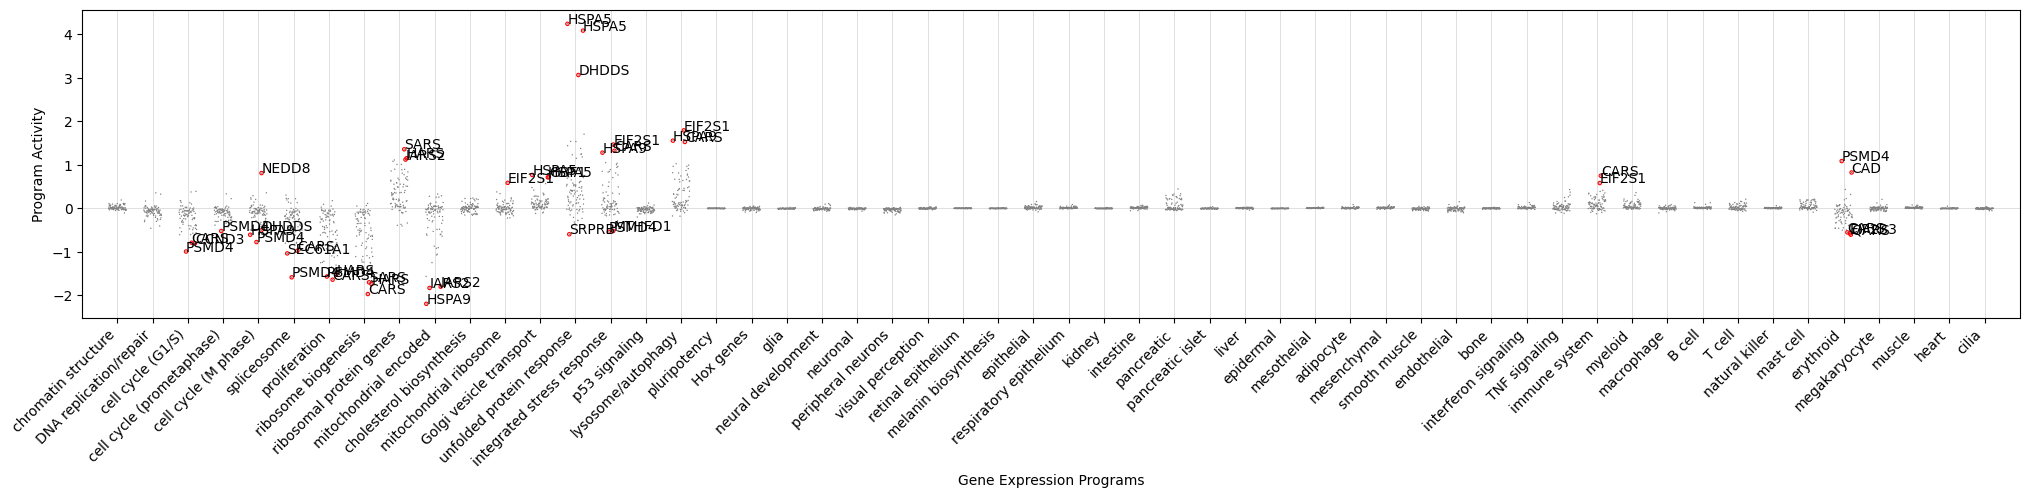

In [11]:
fig, ax = plt.subplots(figsize=(25, 4))

# Plot a column for each expression program
for i in range(len(gene_program_order)):
    x = i - 0.25 + (np.arange(adata_perturb.shape[0]) / adata_perturb.shape[0] / 2)

    idx = adata_perturb.uns['gene_program_names'].index(gene_program_order[i])
    y = adata_perturb.obsm['gene_program'][:, idx]

    ax.axvline(i, color='lightgray', lw=0.5, zorder=-1)
    ax.scatter(x, y, s=1, edgecolor='none', c='gray', rasterized=True)

    # Highlight the top and bottom 3 perturbations
    top_shift_indices = list(np.argsort(y)[:3]) + list(np.argsort(y)[-3:])
    for j in top_shift_indices:
        if np.abs(y[j]) > 0.5:
            ax.text(x[j], y[j], adata_perturb.obs['perturbed_gene'].iloc[j], fontsize=10)
            ax.scatter(x[j], y[j], s=6, edgecolor='red', c='none', linewidth=0.8)
            #print(gene_program_order[i], adata_perturb.obs['perturbed_gene_name'].iloc[j], f'{y[j]:.2f}')


ax.axhline(0, color='lightgray', lw=0.5, zorder=-1)
ax.set_xticks(np.arange(len(gene_program_order)), gene_program_order, rotation=45, ha='right')
ax.set_xlim(-1, len(gene_program_order))
ax.set_xlabel('Gene Expression Programs')
ax.set_ylabel('Program Activity')

plt.show()

Here we can see that the major effect of perturbations are turning on stress response pathways and turning down essential programs such as spliceosome and ribosome biogenesis. But we can also find a few examples, such as PSMD4, that affect the differentiation state of the cell along the erythroid axis.

We can zoom-into the interesting genes to comprehensively visualize their perturbation effects along major axes of cell state transition.

Text(283.22222222222223, 0.5, 'Gene Expression Programs')

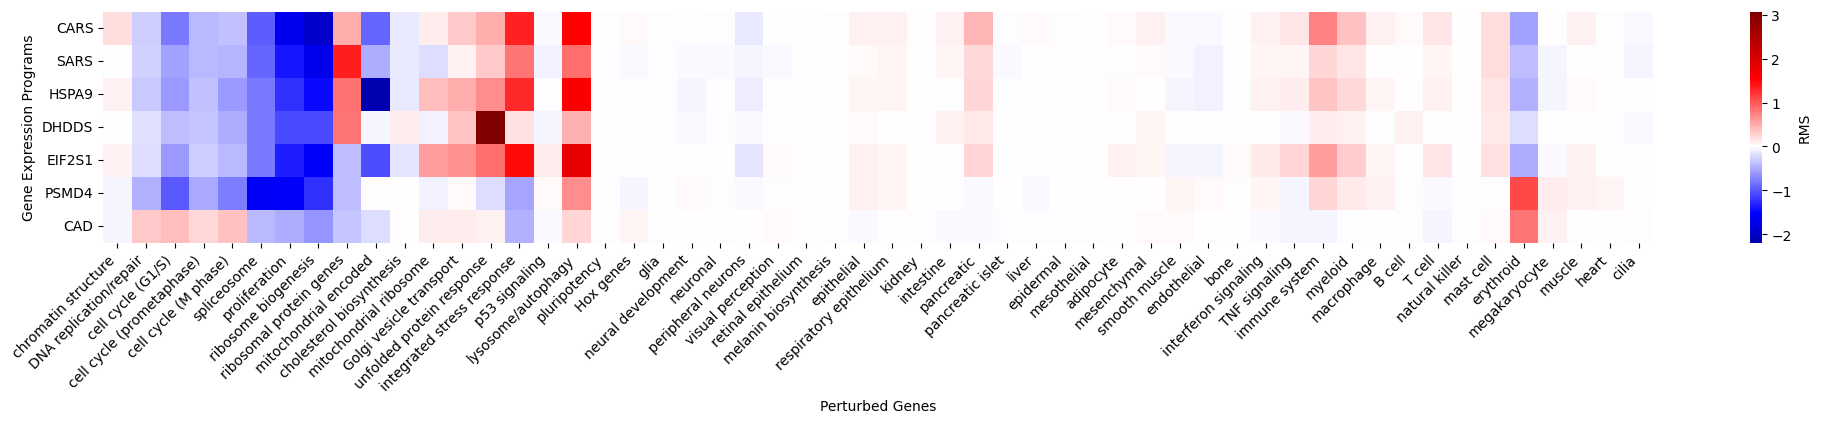

In [12]:
genes_to_show = [
   'CARS', 'SARS', 'HSPA9', 'DHDDS', 'EIF2S1', 'PSMD4', 'CAD', 
     ]

adata_to_show = adata_perturb[adata_perturb.obs['perturbed_gene'].isin(genes_to_show)].copy()
genes_to_show = [g for g in genes_to_show if g in adata_to_show.obs['perturbed_gene'].values]

gene_program_show_df = pd.DataFrame(
    index=adata_to_show.obs['perturbed_gene'],
    columns=adata_to_show.uns['gene_program_names'],
    data=adata_to_show.obsm['gene_program']
)


fig, ax = plt.subplots(figsize=(25, 3))

import seaborn as sns
sns.heatmap(gene_program_show_df.loc[genes_to_show, gene_program_order], cmap='seismic', ax=ax, center=0,
            cbar_kws={'label': 'RMS'})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel('Perturbed Genes')
ax.set_ylabel('Gene Expression Programs')

We can check the perturbation-induced expression of individual genes to validate the collective phenotypes such as the erythroid differentiation caused by PSMD4 and CAD perturbation. 

Let's plot all the genes belonging to the erythroid program.

Text(158.22222222222223, 0.5, 'Perturbed genes')

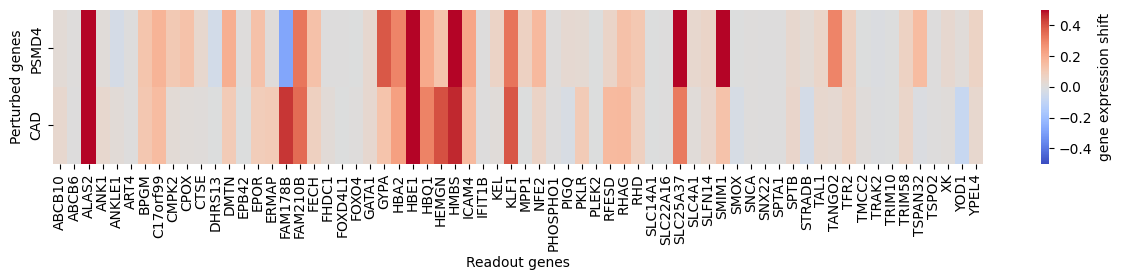

In [13]:
perturbed_genes_to_show = [
    'PSMD4', 'CAD', 

]
perturbed_genes_to_show = [g for g in perturbed_genes_to_show if g in adata_perturb.obs['perturbed_gene'].values]
perturbed_gene_ids = [list(adata_perturb.obs['perturbed_gene']).index(g) for g in perturbed_genes_to_show]

target_genes_to_show = sorted(adata_perturb.var[adata_perturb.var['gene_exp_cluster'] == 'erythroid'
                                                ].index.values)

target_gene_ids = [list(adata_perturb.var.index).index(g) for g in target_genes_to_show]

mtx = adata_perturb.X[perturbed_gene_ids, :][:, target_gene_ids]

fig, ax = plt.subplots(figsize=(15, 2))
sns.heatmap(mtx, cmap='coolwarm', center=0, vmin=-0.5, vmax=0.5,
              xticklabels=target_genes_to_show, yticklabels=perturbed_genes_to_show,
              cbar_kws={'label': 'gene expression shift'},)
plt.xlabel('Readout genes')
plt.ylabel('Perturbed genes')

Indeed, we can see specific marker genes of erythrocytes, such as the hemoglobins (HBA2, HBE1 and HBQ1) and the transcription factor KLF1, being upregulated by knocking down PSMD4 and CAD.

## Grouping of perturbations into universal clusters

So far we have analyzed the principal phenotypes of individual perturbations. We can further gain a comprehensive picture of the coupling between different cellular processes and phenotypes by grouping perturbations into the pre-defined universal clusters.

Let's load the pre-defined clusters and compute the mean perturbation effects of each cluster.

In [14]:
pert_cluster_df = pd.read_csv('data/tutorial_data/perturbation_cluster_annotation.csv', index_col=0)
pg_to_cluster_map = dict(zip(pert_cluster_df['perturbed_gene_name'], pert_cluster_df['cluster_name']))

adata_perturb.obs['cluster_name'] = adata_perturb.obs['perturbed_gene'].map(pg_to_cluster_map)
perturb_group_df = pd.DataFrame(
    index=list(adata_perturb.obs[~adata_perturb.obs['cluster_name'].isna()]['cluster_name'].unique()),
    columns=adata_perturb.uns['gene_program_names'],
    dtype=float,
)

for pg_cluster in perturb_group_df.index:
    pg_genes = list(adata_perturb.obs[adata_perturb.obs['cluster_name'] == pg_cluster].index)
    perturb_group_df.loc[pg_cluster] = adata_perturb[pg_genes].obsm['gene_program'].mean(axis=0)

Let's plot how each perturbation cluster affect the expression of the essential gene expression programs.

Text(70.7222222222222, 0.5, 'Functional clusters')

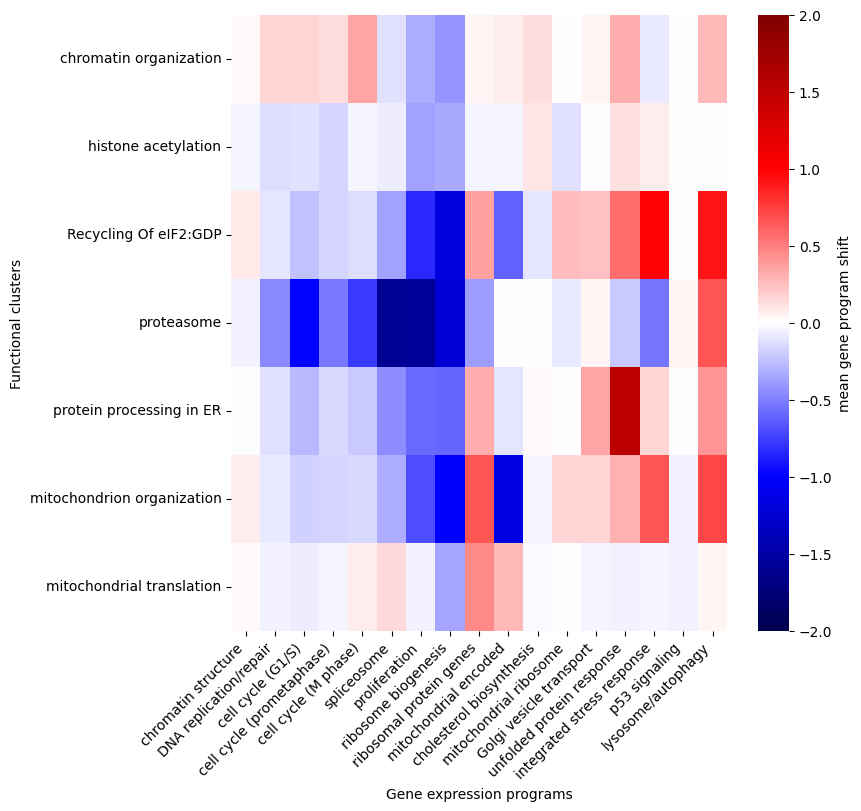

In [15]:
pg_cluster_order = [
    'chromatin organization', 'DNA replication', 'histone acetylation', 'CCT complex', 
    'mediator complex', 'transcription initiation', 'integrator complex', 'pol II transcription', 'pol II enlongation', 
    'spliceosome', 'RNA metabolism', 'RNA degradation', 'RNA methylation', 'mRNA Polyadenylation', 'mRNA surveillance', 
    'ribosome small unit biogenesis', 
    'ribosome small unit protein', 'rRNA processing 1', 'rRNA processing 2', 
    'ribosome large unit biogenesis', 'ribosome large unit protein',
    'translation initiation', 'Recycling Of eIF2:GDP', 
    'protein neddylation', 'proteasome',
    'protein processing in ER', 'membrane fission',
    'mitochondrion organization', 'mitochondrial translation', 'mitochondrial transcription', 
]
pg_cluster_order = [c for c in pg_cluster_order if c in perturb_group_df.index]

gene_program_order = [
    'chromatin structure', 'DNA replication/repair', 'cell cycle (G1/S)', 'cell cycle (prometaphase)', 'cell cycle (M phase)', 
    'spliceosome', 'proliferation',
    'ribosome biogenesis', 'ribosomal protein genes', 'mitochondrial encoded', 'cholesterol biosynthesis', 'mitochondrial ribosome', 
    'Golgi vesicle transport', 'unfolded protein response', 
    'integrated stress response', 'p53 signaling', 'lysosome/autophagy',  
       
    ]


fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(perturb_group_df.loc[pg_cluster_order, gene_program_order],
            cmap='seismic', center=0, cbar_kws={'label': 'mean gene program shift'},
            #xticklabels=False, yticklabels=False,
            vmax=2, vmin=-2,
            ax=ax
            )

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('Gene expression programs')
ax.set_ylabel('Functional clusters')

Several interesting patterns emerge:
1. Proliferation related processes including DNA replication/repair, cell cycle (G1/S), cell cycle (prometaphase), cell cycle (M phase), spliceosome, proliferation and ribosome biogenesis are broadly turned down by diverse perturbations, suggesting perturbation-induced cell cycle arrest.
2. Unlike ribosome biogenesis, which is co-regulated with genes for proliferation, the ribosomal protein genes are regulated with a different pattern, suggesting its responsibility for maintaining other aspects of cellular homeostasis.
3. Stress response pathways are activated by distinct spectra of perturbations. As expected, K562 cells have no p53 signaling. Several perturbation clusters, including recycling of eIF2:GDP, protein processing in ER and mitochondrion organization can activate multiple pathways, including unfolded protein response, integrated stress response and lysosome/autophagy pathways. But perturbation of proteasome selectively activate lysosome/autophagy.